In [73]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import numpy as np

def run_classification(model, model_name, X_train, X_test, y_train, y_test, param_name=None, param_range=None):
    model.fit(X_train, y_train)

    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)

    print(f"\n{model_name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy:  {test_acc:.4f}")


    if param_name is not None and param_range is not None:
        train_scores, test_scores = validation_curve(
            model.__class__(), X_train, y_train,
            param_name=param_name,
            param_range=param_range,
            cv=5,
            scoring='accuracy',
            n_jobs=-1
        )

        train_mean = np.mean(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)

        plt.plot(param_range, train_mean, label="Train Score")
        plt.plot(param_range, test_mean, label="Validation Score")
        plt.xlabel(param_name)
        plt.ylabel("Accuracy")
        plt.title(f"Bias–Variance Trade-off – {model_name}")
        plt.legend()
        plt.grid(True)
        plt.show()



Naive Bayes
Train Accuracy: 0.9444
Test Accuracy:  0.9667

Decision Tree
Train Accuracy: 1.0000
Test Accuracy:  0.9833


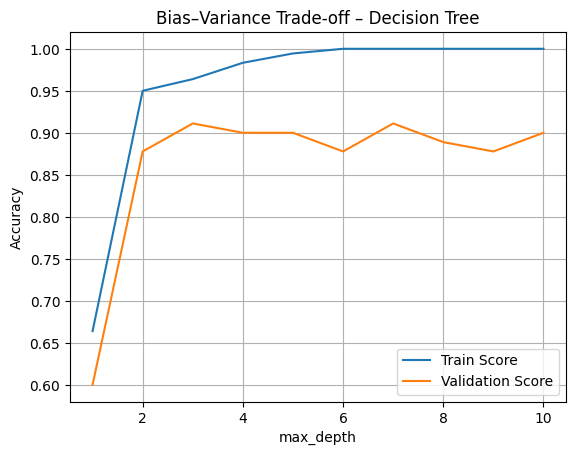


Logistic Regression
Train Accuracy: 0.9556
Test Accuracy:  1.0000


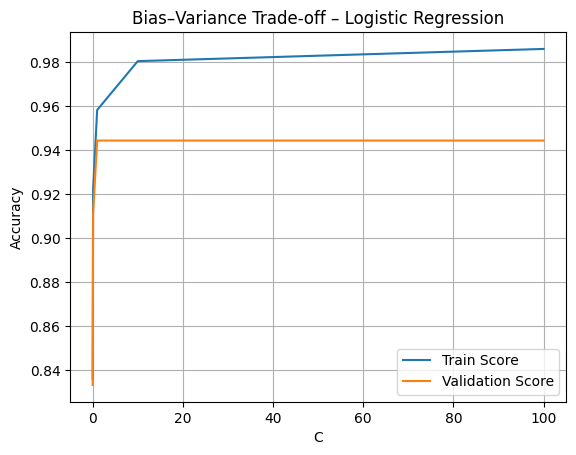

In [74]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

iris = load_iris()
A = iris.data
b = iris.target

X_train, X_test, y_train, y_test = train_test_split(A, b, test_size=0.4, random_state=42)

run_classification(GaussianNB(), "Naive Bayes", X_train, X_test, y_train, y_test)

run_classification(
    DecisionTreeClassifier(), "Decision Tree", X_train, X_test, y_train, y_test,
    param_name='max_depth', param_range=range(1, 11)
)

run_classification(
    LogisticRegression(max_iter=1000), "Logistic Regression", X_train, X_test, y_train, y_test,
    param_name='C', param_range=np.logspace(-2, 2, 5)
)


In [77]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

car_df = pd.read_csv(r"C:\Users\Lenovo\Downloads\car.data", header=None)

car_df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

le = LabelEncoder()
for col in car_df.columns:
    car_df[col] = le.fit_transform(car_df[col])

X = car_df.drop('class', axis=1)
y = car_df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



Naive Bayes
Train Accuracy: 0.6404
Test Accuracy:  0.6243

Decision Tree
Train Accuracy: 1.0000
Test Accuracy:  0.9740


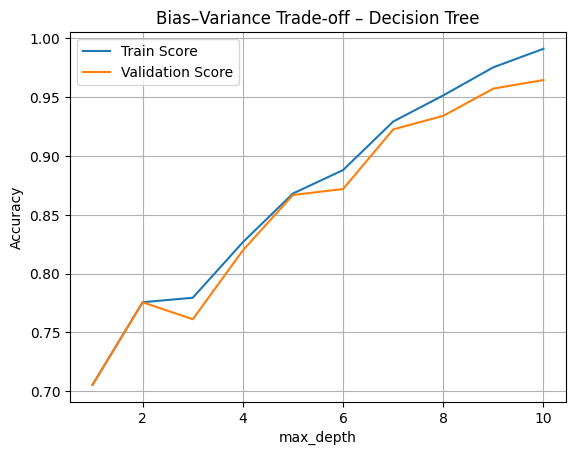


Logistic Regression
Train Accuracy: 0.7033
Test Accuracy:  0.6590


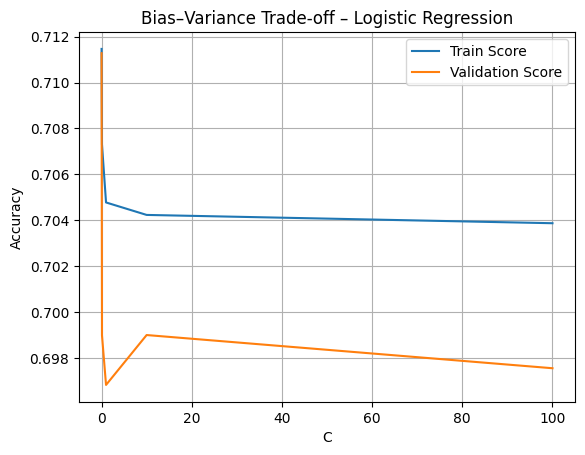

In [78]:

run_classification(GaussianNB(), "Naive Bayes", X_train, X_test, y_train, y_test)

run_classification(
    DecisionTreeClassifier(), "Decision Tree", X_train, X_test, y_train, y_test,
    param_name='max_depth', param_range=range(1, 11)
)

run_classification(
    LogisticRegression(max_iter=1000), "Logistic Regression", X_train, X_test, y_train, y_test,
    param_name='C', param_range=np.logspace(-2, 2, 5)
)


In [86]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error


def run_regression_models(X, y, dataset_name="Dataset"):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"\n{dataset_name} - Linear Regression")
    model = LinearRegression()
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    print(f"Train MSE: {mean_squared_error(y_train, train_pred):.4f}")
    print(f"Test MSE: {mean_squared_error(y_test, test_pred):.4f}")

    print(f"\n{dataset_name} - SVR (Bias–Variance Trade-off)")
    C_values = [0.01, 0.1, 1, 10, 100]
    train_errors, test_errors = [], []

    for C in C_values:
        svr = SVR(C=C)
        svr.fit(X_train, y_train)
        train_preds = svr.predict(X_train)
        test_preds = svr.predict(X_test)

        train_mse = mean_squared_error(y_train, train_preds)
        test_mse = mean_squared_error(y_test, test_preds)
        train_errors.append(train_mse)
        test_errors.append(test_mse)

        print(f"C={C}: Train MSE={train_mse:.4f}, Test MSE={test_mse:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(C_values, train_errors, label='Train MSE', marker='o')
    plt.plot(C_values, test_errors, label='Test MSE', marker='o')
    plt.xscale('log')
    plt.xlabel("C (SVR)")
    plt.ylabel("Mean Squared Error")
    plt.title(f"{dataset_name} - SVR Bias–Variance Trade-off")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



Abalone - Linear Regression
Train MSE: 4.8009
Test MSE: 4.9503

Abalone - SVR (Bias–Variance Trade-off)
C=0.01: Train MSE=7.8553, Test MSE=8.0191
C=0.1: Train MSE=6.6383, Test MSE=6.7996
C=1: Train MSE=5.0869, Test MSE=5.2982
C=10: Train MSE=4.4730, Test MSE=4.7455
C=100: Train MSE=4.3089, Test MSE=4.5950


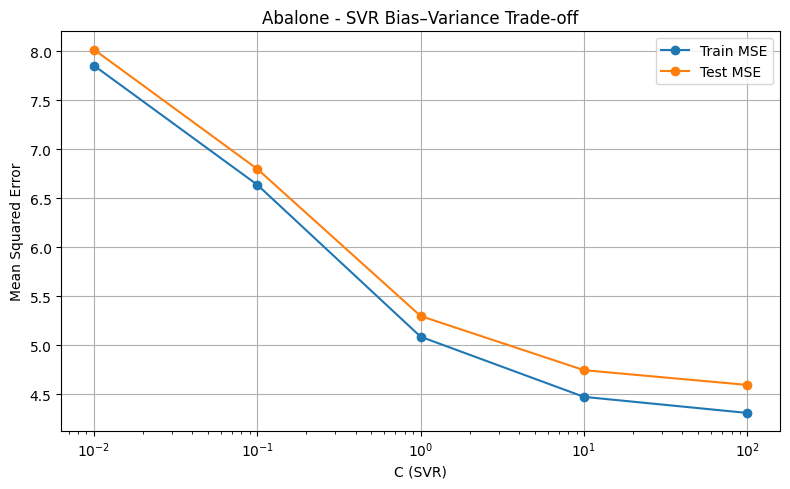

In [87]:

df = pd.read_csv(r"C:\Users\Lenovo\Downloads\abalone.data", header=None)
df.columns = ['Sex', 'Length', 'Diameter', 'Height', 'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 'ShellWeight', 'Rings']
df['Sex'] = pd.factorize(df['Sex'])[0]

X = df.drop('Rings', axis=1)
y = df['Rings']

run_regression_models(X, y, dataset_name="Abalone")


In [83]:
df.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7



Iris - Linear Regression
Train MSE: 0.0919
Test MSE: 0.1300

Iris - SVR (Bias–Variance Trade-off)
C=0.01: Train MSE=2.8587, Test MSE=2.9362
C=0.1: Train MSE=0.5181, Test MSE=0.5572
C=1: Train MSE=0.0950, Test MSE=0.1297
C=10: Train MSE=0.0673, Test MSE=0.0872
C=100: Train MSE=0.0555, Test MSE=0.0862


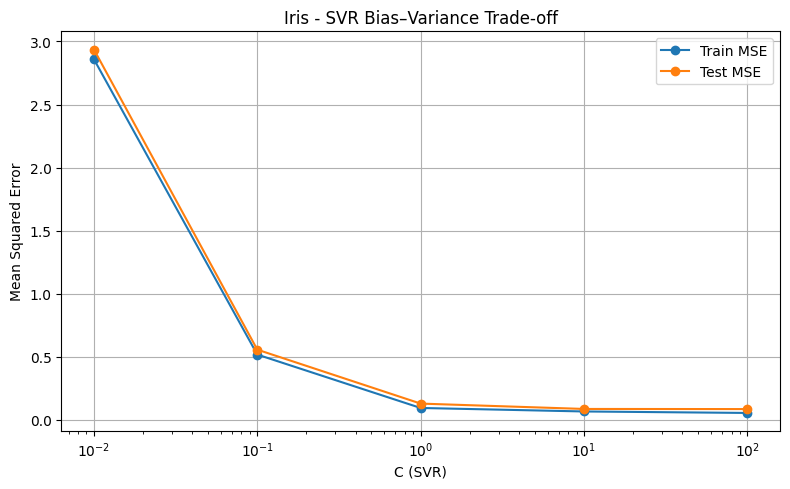

In [81]:


iris = load_iris(as_frame=True)
df = iris.frame

X = df.drop(['petal length (cm)', 'target'], axis=1)
y = df['petal length (cm)']

run_regression_models(X, y, dataset_name="Iris")
